# DeepFashion-MultiModal Visual EDA

**Owner:** Dasith  
**Purpose:** Explore DeepFashion-MultiModal images and the available visual attribute labels for classification planning.

This notebook does not train a model, modify raw data, or load the complete image collection into memory. All counts, targets, and conclusions are derived from the files available at runtime.

In [10]:
from pathlib import Path
from collections import Counter
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from IPython.display import display, Markdown

RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
plt.style.use('default')

def find_repository_root(start=None):
    start = Path(start or Path.cwd()).resolve()
    candidates = [start, *start.parents]
    for candidate in candidates:
        if (candidate / 'config.yaml').is_file() and (candidate / 'data' / 'raw' / 'deepfashion').is_dir():
            return candidate
    raise FileNotFoundError('Could not find repository root containing config.yaml and data/raw/deepfashion.')

REPO_ROOT = find_repository_root()
DATASET_ROOT = REPO_ROOT / 'data' / 'raw' / 'deepfashion'
FIGURES_ROOT = REPO_ROOT / 'outputs' / 'figures'
FIGURES_ROOT.mkdir(parents=True, exist_ok=True)
print(f'Repository root: {REPO_ROOT}')
print(f'Dataset root: {DATASET_ROOT}')

Repository root: D:\Deep Learning\Project\GITHUB\Explainable-Fashion-Design-AI
Dataset root: D:\Deep Learning\Project\GITHUB\Explainable-Fashion-Design-AI\data\raw\deepfashion


## 1. Dataset components and file inventory

The availability check is intentionally explicit. Some DeepFashion releases contain auxiliary components that may not be present in every local copy.

In [11]:
expected_components = ['images', 'labels', 'captions.json', 'segm', 'keypoints', 'densepose']
component_rows = []
for name in expected_components:
    path = DATASET_ROOT / name
    component_rows.append({'component': name, 'path': str(path), 'exists': path.exists(), 'type': 'directory' if path.is_dir() else 'file' if path.is_file() else 'missing'})
component_status = pd.DataFrame(component_rows)
display(component_status)

if not DATASET_ROOT.is_dir():
    raise FileNotFoundError(f'Dataset directory does not exist: {DATASET_ROOT}')

image_root = DATASET_ROOT / 'images'
label_root = DATASET_ROOT / 'labels'
image_files = sorted([p for p in image_root.rglob('*') if p.is_file()]) if image_root.is_dir() else []
image_extensions = Counter(p.suffix.lower() or '[no extension]' for p in image_files)
print(f'Image files found: {len(image_files):,}')
display(pd.DataFrame(image_extensions.most_common(), columns=['extension', 'count']))
print('Example image paths:')
display(pd.DataFrame({'image': [str(p.relative_to(DATASET_ROOT)) for p in image_files[:10]]}))

,component,path,exists,type
0,images,D:\Deep Learning\Project\GITHUB\Explainable-Fa...,True,directory
1,labels,D:\Deep Learning\Project\GITHUB\Explainable-Fa...,True,directory
2,captions.json,D:\Deep Learning\Project\GITHUB\Explainable-Fa...,True,file
3,segm,D:\Deep Learning\Project\GITHUB\Explainable-Fa...,True,directory
4,keypoints,D:\Deep Learning\Project\GITHUB\Explainable-Fa...,True,directory
5,densepose,D:\Deep Learning\Project\GITHUB\Explainable-Fa...,True,directory


Image files found: 44,096


,extension,count
0,.jpg,44096


Example image paths:


,image
0,images\MEN-Denim-id_00000080-01_7_additional.jpg
1,images\MEN-Denim-id_00000089-01_7_additional.jpg
2,images\MEN-Denim-id_00000089-02_7_additional.jpg
3,images\MEN-Denim-id_00000089-03_7_additional.jpg
4,images\MEN-Denim-id_00000089-04_7_additional.jpg
5,images\MEN-Denim-id_00000089-05_7_additional.jpg
6,images\MEN-Denim-id_00000089-08_4_full.jpg
7,images\MEN-Denim-id_00000089-15_4_full.jpg
8,images\MEN-Denim-id_00000089-17_4_full.jpg
9,images\MEN-Denim-id_00000089-18_4_full.jpg


## 2. Inspect the actual labels

Label files are discovered recursively. Each non-empty line is parsed as a filename followed by its observed whitespace-delimited values. Because the files have no headers, the notebook names columns using the actual relative label filename and value position rather than assuming semantic attribute names.

In [12]:
label_files = sorted(label_root.rglob('*')) if label_root.is_dir() else []
label_files = [p for p in label_files if p.is_file()]
print(f'Label files found: {len(label_files):,}')

label_tables = {}
label_inventory = []
for label_path in label_files:
    rows = []
    malformed = []
    with label_path.open('r', encoding='utf-8', errors='replace') as handle:
        for line_number, line in enumerate(handle, start=1):
            tokens = line.strip().split()
            if not tokens:
                continue
            if len(tokens) < 2:
                malformed.append(line_number)
                continue
            values = []
            for token in tokens[1:]:
                try:
                    values.append(int(token))
                except ValueError:
                    try:
                        values.append(float(token))
                    except ValueError:
                        values.append(token)
            rows.append([tokens[0], *values])
    relative_name = str(label_path.relative_to(label_root)).replace('\\', '/')
    width = max((len(row) for row in rows), default=1)
    columns = ['image_name'] + [f'{relative_name}__value_{i}' for i in range(1, width)]
    table = pd.DataFrame([row + [np.nan] * (width - len(row)) for row in rows], columns=columns)
    label_tables[relative_name] = table
    label_inventory.append({'label_file': relative_name, 'records': len(table), 'value_columns': len(columns) - 1, 'malformed_lines': len(malformed), 'duplicate_image_records': int(table['image_name'].duplicated().sum()) if not table.empty else 0})

label_inventory_df = pd.DataFrame(label_inventory)
display(label_inventory_df)
for name, table in label_tables.items():
    print(f'\n{name}: first five parsed records')
    display(table.head())

Label files found: 3


,label_file,records,value_columns,malformed_lines,duplicate_image_records
0,shape/shape_anno_all.txt,42544,12,0,0
1,texture/fabric_ann.txt,44096,3,0,0
2,texture/pattern_ann.txt,44096,3,0,0



shape/shape_anno_all.txt: first five parsed records


,image_name,shape/shape_anno_all.txt__value_1,shape/shape_anno_all.txt__value_2,shape/shape_anno_all.txt__value_3,shape/shape_anno_all.txt__value_4,shape/shape_anno_all.txt__value_5,shape/shape_anno_all.txt__value_6,shape/shape_anno_all.txt__value_7,shape/shape_anno_all.txt__value_8,shape/shape_anno_all.txt__value_9,shape/shape_anno_all.txt__value_10,shape/shape_anno_all.txt__value_11,shape/shape_anno_all.txt__value_12
0,MEN-Denim-id_00000080-01_7_additional.jpg,5,3,0,0,0,0,0,0,3,2,1,1
1,MEN-Denim-id_00000089-01_7_additional.jpg,0,3,0,0,0,0,0,0,3,2,1,1
2,MEN-Denim-id_00000089-02_7_additional.jpg,3,3,0,0,0,0,0,0,3,4,1,1
3,MEN-Denim-id_00000089-03_7_additional.jpg,1,3,0,0,0,0,0,0,3,2,1,1
4,MEN-Denim-id_00000089-04_7_additional.jpg,3,3,0,0,0,0,0,0,3,4,1,1



texture/fabric_ann.txt: first five parsed records


,image_name,texture/fabric_ann.txt__value_1,texture/fabric_ann.txt__value_2,texture/fabric_ann.txt__value_3
0,MEN-Denim-id_00000080-01_7_additional.jpg,1,1,7
1,MEN-Denim-id_00000089-01_7_additional.jpg,1,1,7
2,MEN-Denim-id_00000089-02_7_additional.jpg,1,1,7
3,MEN-Denim-id_00000089-03_7_additional.jpg,1,1,7
4,MEN-Denim-id_00000089-04_7_additional.jpg,0,1,7



texture/pattern_ann.txt: first five parsed records


,image_name,texture/pattern_ann.txt__value_1,texture/pattern_ann.txt__value_2,texture/pattern_ann.txt__value_3
0,MEN-Denim-id_00000080-01_7_additional.jpg,3,4,7
1,MEN-Denim-id_00000089-01_7_additional.jpg,3,3,7
2,MEN-Denim-id_00000089-02_7_additional.jpg,2,3,7
3,MEN-Denim-id_00000089-03_7_additional.jpg,3,3,7
4,MEN-Denim-id_00000089-04_7_additional.jpg,3,3,7


## 3. Image-label matching and target discovery

Matching uses the actual image basename. The target table below retains one column for every observed value position in every real label file. This makes missing labels and potential classification targets visible without fabricating attribute names.

In [13]:
image_name_to_paths = {}
for path in image_files:
    image_name_to_paths.setdefault(path.name, []).append(path)
duplicate_image_names = {name: paths for name, paths in image_name_to_paths.items() if len(paths) > 1}

FABRIC_LABEL_FILE = 'texture/fabric_ann.txt'
FABRIC_FIELDS = {
    'upper_fabric': f'{FABRIC_LABEL_FILE}__value_1',
    'lower_fabric': f'{FABRIC_LABEL_FILE}__value_2',
    'outer_fabric': f'{FABRIC_LABEL_FILE}__value_3',
}
FABRIC_ID_TO_LABEL = {
    0: 'denim', 1: 'cotton', 2: 'leather', 3: 'furry',
    4: 'knitted', 5: 'chiffon', 6: 'other', 7: 'NA',
}
EXCLUDE_NA_TARGET = True
MIN_CLASS_SAMPLES = 100

label_frames = []
for label_file, table in label_tables.items():
    frame = table.drop_duplicates('image_name', keep='first').set_index('image_name')
    label_frames.append(frame)
labels_wide = pd.concat(label_frames, axis=1) if label_frames else pd.DataFrame()
image_names = pd.Index([p.name for p in image_files], name='image_name')

fabric_rows = []
for semantic_name, raw_column in FABRIC_FIELDS.items():
    series = labels_wide[raw_column].reindex(image_names).dropna()
    counts = series.map(FABRIC_ID_TO_LABEL).value_counts().sort_index()
    rare_labels = counts[counts < MIN_CLASS_SAMPLES].index.tolist()
    fabric_rows.append({
        'semantic_target': semantic_name,
        'raw_column': raw_column,
        'matched_images': int(series.notna().sum()),
        'coverage': float(series.notna().mean()) if len(image_names) else np.nan,
        'n_classes_including_NA': int(series.nunique()),
        'na_count': int((series == 7).sum()),
        'na_percentage': float((series == 7).mean() * 100) if len(series) else np.nan,
        'usable_after_NA_policy': int((series != 7).sum()) if EXCLUDE_NA_TARGET else int(len(series)),
        'minimum_class_count': int(counts.min()) if len(counts) else 0,
        'rare_classes_below_threshold': ', '.join(rare_labels) if rare_labels else 'none',
        'class_distribution': counts.to_dict(),
    })
fabric_target_report = pd.DataFrame(fabric_rows)
print(f'Image names with duplicate paths: {len(duplicate_image_names):,}')
display(fabric_target_report)
print(f'Label records whose image filename is absent from images/: {sum((~table.index.isin(image_name_to_paths)).sum() for table in label_frames):,}')

Image names with duplicate paths: 0


,semantic_target,raw_column,matched_images,coverage,n_classes_including_NA,na_count,na_percentage,usable_after_NA_policy,minimum_class_count,rare_classes_below_threshold,class_distribution
0,upper_fabric,texture/fabric_ann.txt__value_1,44096,1.0,8,998,2.263244,43098,94,"leather, other","{'NA': 998, 'chiffon': 5142, 'cotton': 34734, ..."
1,lower_fabric,texture/fabric_ann.txt__value_2,44096,1.0,8,1326,3.007075,42770,15,furry,"{'NA': 1326, 'chiffon': 2252, 'cotton': 19073,..."
2,outer_fabric,texture/fabric_ann.txt__value_3,44096,1.0,8,38471,87.243741,5625,20,other,"{'NA': 38471, 'chiffon': 407, 'cotton': 2979, ..."


Label records whose image filename is absent from images/: 0


## 4. Class distributions and imbalance

For each discovered target, the notebook reports observed class counts, the number of classes, the majority-class share, and the minority-to-majority ratio. These are computed only from matched, non-missing records.

,semantic_target,majority_share,max_to_min_ratio,minority_to_majority_ratio,class_counts
0,upper_fabric,0.787690,369.510638,0.002706,"{'NA': 998, 'chiffon': 5142, 'cotton': 34734, ..."
1,lower_fabric,0.434983,1278.733333,0.000782,"{'NA': 1326, 'chiffon': 2252, 'cotton': 19073,..."
2,outer_fabric,0.872437,1923.550000,0.000520,"{'NA': 38471, 'chiffon': 407, 'cotton': 2979, ..."


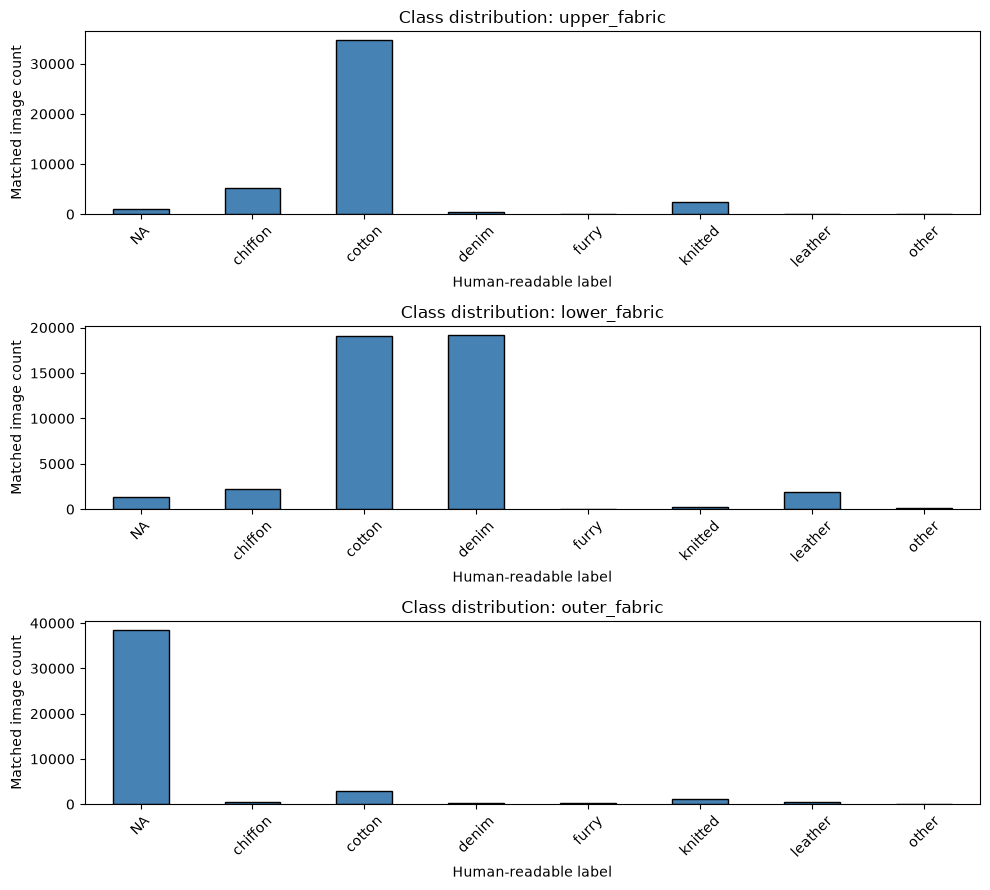

In [14]:
distribution_rows = []
distributions = {}
for semantic_name, raw_column in FABRIC_FIELDS.items():
    series = labels_wide[raw_column].reindex(image_names).dropna()
    counts = series.map(FABRIC_ID_TO_LABEL).value_counts().sort_index()
    distributions[semantic_name] = counts
    if len(counts):
        majority = int(counts.max())
        minority = int(counts.min())
        distribution_rows.append({
            'semantic_target': semantic_name,
            'majority_share': majority / counts.sum(),
            'max_to_min_ratio': majority / minority if minority else np.inf,
            'minority_to_majority_ratio': minority / majority if majority else np.nan,
            'class_counts': counts.to_dict(),
        })
distribution_report = pd.DataFrame(distribution_rows)
display(distribution_report)

if distributions:
    fig, axes = plt.subplots(len(distributions), 1, figsize=(10, max(4, 3 * len(distributions))), squeeze=False)
    for ax, (semantic_name, counts) in zip(axes.ravel(), distributions.items()):
        counts.plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')
        ax.set_title(f'Class distribution: {semantic_name}')
        ax.set_xlabel('Human-readable label')
        ax.set_ylabel('Matched image count')
        ax.tick_params(axis='x', rotation=45)
    fig.tight_layout()
    fig.savefig(FIGURES_ROOT / 'dasith_deepfashion_visual_class_distribution.png', dpi=150, bbox_inches='tight')
    plt.show()
    plt.close(fig)

## 5. Sample image properties

Images are opened one at a time and immediately closed. Only the small sampled metadata table is retained; the complete image collection is never loaded into RAM.

,image_name,width,height,aspect_ratio,mode
0,WOMEN-Tees_Tanks-id_00006581-14_3_back.jpg,750,1101,0.681199,RGB
1,WOMEN-Blouses_Shirts-id_00001962-01_4_full.jpg,750,1101,0.681199,RGB
2,MEN-Sweaters-id_00000016-01_1_front.jpg,750,1101,0.681199,RGB
3,WOMEN-Dresses-id_00004091-06_3_back.jpg,750,1101,0.681199,RGB
4,WOMEN-Dresses-id_00001714-01_2_side.jpg,750,1101,0.681199,RGB


,width,height,aspect_ratio
count,1000.0,1000.000000,1000.000000
mean,750.0,1100.814000,0.681337
std,0.0,5.881836,0.004379
min,750.0,915.000000,0.681199
25%,750.0,1101.000000,0.681199
50%,750.0,1101.000000,0.681199
75%,750.0,1101.000000,0.681199
max,750.0,1101.000000,0.819672


,count
mode,
RGB,1000


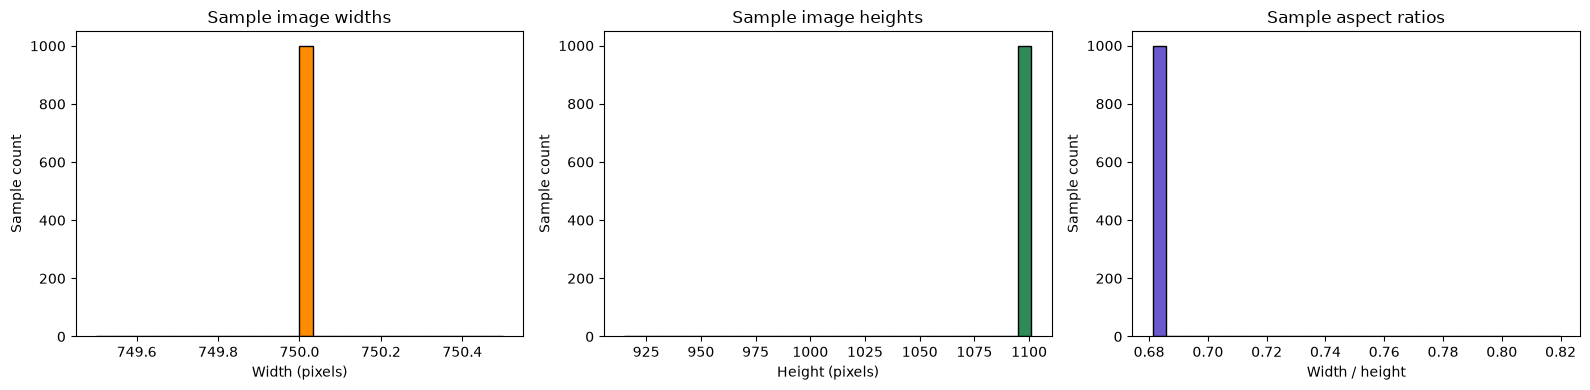

In [15]:
sample_size = min(1000, len(image_files))
sampled_paths = random.sample(image_files, sample_size) if sample_size else []
property_rows = []
for path in sampled_paths:
    try:
        with Image.open(path) as image:
            width, height = image.size
            property_rows.append({'image_name': path.name, 'width': width, 'height': height, 'aspect_ratio': width / height if height else np.nan, 'mode': image.mode})
    except (OSError, ValueError) as exc:
        property_rows.append({'image_name': path.name, 'width': np.nan, 'height': np.nan, 'aspect_ratio': np.nan, 'mode': f'ERROR: {type(exc).__name__}'})

image_properties = pd.DataFrame(property_rows)
display(image_properties.head())
display(image_properties[['width', 'height', 'aspect_ratio']].describe())
display(image_properties['mode'].value_counts(dropna=False).rename_axis('mode').to_frame('count'))

numeric_properties = image_properties.dropna(subset=['width', 'height', 'aspect_ratio'])
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
numeric_properties['width'].plot.hist(ax=axes[0], bins=30, color='darkorange', edgecolor='black')
numeric_properties['height'].plot.hist(ax=axes[1], bins=30, color='seagreen', edgecolor='black')
numeric_properties['aspect_ratio'].plot.hist(ax=axes[2], bins=30, color='slateblue', edgecolor='black')
axes[0].set_title('Sample image widths'); axes[0].set_xlabel('Width (pixels)')
axes[1].set_title('Sample image heights'); axes[1].set_xlabel('Height (pixels)')
axes[2].set_title('Sample aspect ratios'); axes[2].set_xlabel('Width / height')
for ax in axes: ax.set_ylabel('Sample count')
fig.tight_layout()
fig.savefig(FIGURES_ROOT / 'dasith_deepfashion_visual_image_properties.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close(fig)

sample_size = min(1000, len(image_files))
sampled_paths = random.sample(image_files, sample_size) if sample_size else []
property_rows = []
for path in sampled_paths:
    try:
        with Image.open(path) as image:
            width, height = image.size
            property_rows.append({'image_name': path.name, 'width': width, 'height': height, 'aspect_ratio': width / height if height else np.nan, 'mode': image.mode})
    except (OSError, ValueError) as exc:
        property_rows.append({'image_name': path.name, 'width': np.nan, 'height': np.nan, 'aspect_ratio': np.nan, 'mode': f'ERROR: {type(exc).__name__}'})

image_properties = pd.DataFrame(property_rows)
display(image_properties.head())
display(image_properties[['width', 'height', 'aspect_ratio']].describe())
display(image_properties['mode'].value_counts(dropna=False).rename_axis('mode').to_frame('count'))

numeric_properties = image_properties.dropna(subset=['width', 'height', 'aspect_ratio'])
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
numeric_properties['width'].plot.hist(ax=axes[0], bins=30, color='darkorange', edgecolor='black')
numeric_properties['height'].plot.hist(ax=axes[1], bins=30, color='seagreen', edgecolor='black')
numeric_properties['aspect_ratio'].plot.hist(ax=axes[2], bins=30, color='slateblue', edgecolor='black')
axes[0].set_title('Sample image widths'); axes[0].set_xlabel('Width (pixels)')
axes[1].set_title('Sample image heights'); axes[1].set_xlabel('Height (pixels)')
axes[2].set_title('Sample aspect ratios'); axes[2].set_xlabel('Width / height')
for ax in axes: ax.set_ylabel('Sample count')
fig.tight_layout()
fig.savefig(FIGURES_ROOT / 'dasith_deepfashion_visual_image_properties.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close(fig)

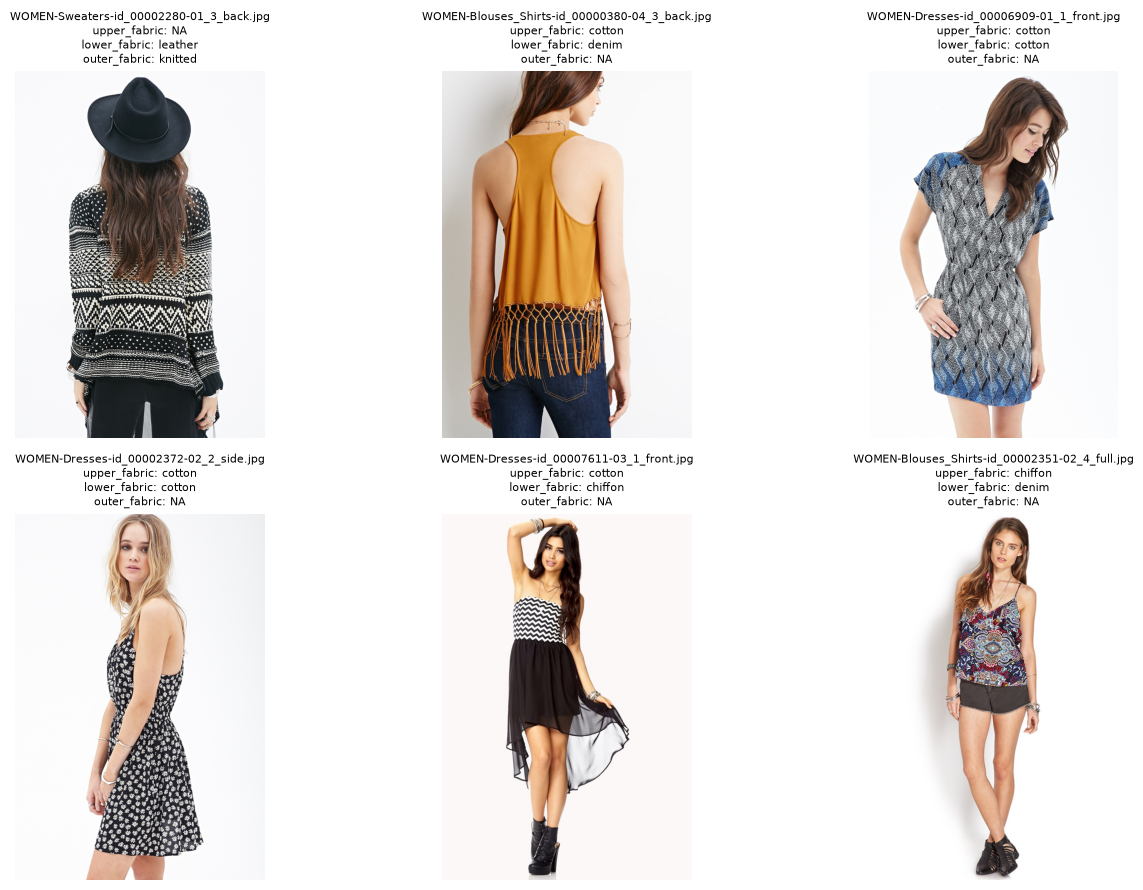

In [16]:
display_count = min(6, len(image_files))
display_paths = random.sample(image_files, display_count) if display_count else []
fig, axes = plt.subplots(2, 3, figsize=(14, 9))
axes = np.asarray(axes).ravel()
for ax in axes:
    ax.axis('off')
for ax, path in zip(axes, display_paths):
    with Image.open(path) as image:
        ax.imshow(image.copy())
    if path.name in labels_wide.index:
        label_values = {}
        for semantic_name, raw_column in FABRIC_FIELDS.items():
            raw_value = labels_wide.loc[path.name, raw_column]
            label_values[semantic_name] = FABRIC_ID_TO_LABEL.get(int(raw_value), 'unknown') if pd.notna(raw_value) else 'missing'
        label_text = '\n'.join(f'{key}: {value}' for key, value in label_values.items())
    else:
        label_text = 'No matching fabric labels'
    ax.set_title(f'{path.name}\n{label_text}', fontsize=8)
fig.tight_layout()
fig.savefig(FIGURES_ROOT / 'dasith_deepfashion_visual_labeled_examples.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close(fig)

## 7. Classification suitability and CLIP rationale

The following rule selects a candidate from the observed targets: maximize label coverage first, then prefer the smallest majority-class share, then prefer more than one observed class. This is a transparent EDA heuristic, not a model result.

In [17]:
selected_target = 'lower_fabric'
selected_target_row = fabric_target_report.loc[fabric_target_report['semantic_target'] == selected_target].iloc[0]
print(f'Configured classification target: {selected_target}')
print('Reason: lower_fabric is the project-defined target for downstream classification. The table below exposes coverage, NA percentage, rare classes, sample volume, and imbalance for an explicit review rather than silently choosing a target by one metric.')
display(fabric_target_report)

display(Markdown('''### Target-selection conclusion

The downstream target is explicitly set to **lower_fabric**, decoded from the second value in `texture/fabric_ann.txt`. This choice is a project decision grounded in semantic usefulness for fabric classification, not an automatic ranking by coverage or majority share. ID `7` is the real dataset value for `NA`; its treatment is controlled by `EXCLUDE_NA_TARGET`. Classes below `MIN_CLASS_SAMPLES` are reported for later preprocessing review. No model is trained in this notebook.

### Why CLIP embeddings are useful

CLIP maps images and text into a shared embedding space learned from image-text pairs. For this project, an image embedding can provide a compact semantic visual representation for downstream attribute classification, similarity search, generation conditioning, and explainability comparisons. CLIP embeddings are features, not labels: target quality, NA handling, rare-class policy, and image-label matching still need to be validated.'''))

Configured classification target: lower_fabric
Reason: lower_fabric is the project-defined target for downstream classification. The table below exposes coverage, NA percentage, rare classes, sample volume, and imbalance for an explicit review rather than silently choosing a target by one metric.


,semantic_target,raw_column,matched_images,coverage,n_classes_including_NA,na_count,na_percentage,usable_after_NA_policy,minimum_class_count,rare_classes_below_threshold,class_distribution
0,upper_fabric,texture/fabric_ann.txt__value_1,44096,1.0,8,998,2.263244,43098,94,"leather, other","{'NA': 998, 'chiffon': 5142, 'cotton': 34734, ..."
1,lower_fabric,texture/fabric_ann.txt__value_2,44096,1.0,8,1326,3.007075,42770,15,furry,"{'NA': 1326, 'chiffon': 2252, 'cotton': 19073,..."
2,outer_fabric,texture/fabric_ann.txt__value_3,44096,1.0,8,38471,87.243741,5625,20,other,"{'NA': 38471, 'chiffon': 407, 'cotton': 2979, ..."


### Target-selection conclusion

The downstream target is explicitly set to **lower_fabric**, decoded from the second value in `texture/fabric_ann.txt`. This choice is a project decision grounded in semantic usefulness for fabric classification, not an automatic ranking by coverage or majority share. ID `7` is the real dataset value for `NA`; its treatment is controlled by `EXCLUDE_NA_TARGET`. Classes below `MIN_CLASS_SAMPLES` are reported for later preprocessing review. No model is trained in this notebook.

### Why CLIP embeddings are useful

CLIP maps images and text into a shared embedding space learned from image-text pairs. For this project, an image embedding can provide a compact semantic visual representation for downstream attribute classification, similarity search, generation conditioning, and explainability comparisons. CLIP embeddings are features, not labels: target quality, NA handling, rare-class policy, and image-label matching still need to be validated.

## 8. EDA summary and conclusion

Run this final cell after the preceding cells to generate a data-derived summary. The conclusion deliberately avoids fixed counts or claims so it remains correct for the local dataset copy.

In [18]:
summary_lines = [
    f'- Repository root detected at: `{REPO_ROOT}`',
    f'- Image files discovered: **{len(image_files):,}** across extensions {dict(image_extensions)}.',
    f'- Label files discovered: **{len(label_files):,}**; duplicate image basenames in the image tree: **{len(duplicate_image_names):,}**.',
    f'- Fabric targets decoded semantically: **upper_fabric**, **lower_fabric**, and **outer_fabric**.',
    f'- Configured downstream target: **{selected_target}**; ID 7 is explicitly decoded as **NA**.',
    f'- EDA rare-class threshold: **{MIN_CLASS_SAMPLES}** samples; NA exclusion policy: **{EXCLUDE_NA_TARGET}**.',
    f'- Image metadata was sampled from **{len(image_properties):,}** files, with one-image-at-a-time PIL reads.',
    f'- Figures were saved under `{FIGURES_ROOT}` with prefix `dasith_deepfashion_visual_`.',
    '- Conclusion: label quality and class imbalance must be handled explicitly during preprocessing; no model performance is claimed by this EDA.',
    '- No model was trained, no raw file was modified, and no complete image collection was loaded into RAM.',
]
display(Markdown('\n'.join(summary_lines)))

- Repository root detected at: `D:\Deep Learning\Project\GITHUB\Explainable-Fashion-Design-AI`
- Image files discovered: **44,096** across extensions {'.jpg': 44096}.
- Label files discovered: **3**; duplicate image basenames in the image tree: **0**.
- Fabric targets decoded semantically: **upper_fabric**, **lower_fabric**, and **outer_fabric**.
- Configured downstream target: **lower_fabric**; ID 7 is explicitly decoded as **NA**.
- EDA rare-class threshold: **100** samples; NA exclusion policy: **True**.
- Image metadata was sampled from **1,000** files, with one-image-at-a-time PIL reads.
- Figures were saved under `D:\Deep Learning\Project\GITHUB\Explainable-Fashion-Design-AI\outputs\figures` with prefix `dasith_deepfashion_visual_`.
- Conclusion: label quality and class imbalance must be handled explicitly during preprocessing; no model performance is claimed by this EDA.
- No model was trained, no raw file was modified, and no complete image collection was loaded into RAM.